In [230]:
#importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [231]:
import io
%cd '/Users/Wrick/Downloads'

/Users/Wrick/Downloads


In [232]:
#loading the dataset
singapore = pd.read_excel("P_Data_Extract_From_World_Development_Indicators (1).xlsx", sheet_name="SingaporeData")

In [233]:
#listing the columns
singapore.columns

Index(['Year', 'Birth rate, crude (per 1,000 people)',
       'CO2 emissions (metric tons per capita)',
       'Current account balance (% of GDP)',
       'Current health expenditure (% of GDP)', 'Expense (% of GDP)',
       'Exports of goods and services (% of GDP)',
       'Fertility rate, total (births per woman)',
       'Final consumption expenditure (% of GDP)',
       'Foreign direct investment, net inflows (% of GDP)',
       'Foreign direct investment, net outflows (% of GDP)',
       'Food exports (% of merchandise exports)',
       'Food imports (% of merchandise imports)',
       'Foreign direct investment, net (BoP, current US$)',
       'GDP growth (annual %)', 'GDP per capita growth (annual %)',
       'GNI growth (annual %)', 'GNI per capita growth (annual %)',
       'Goods and services expense (% of expense)',
       'Gross capital formation (% of GDP)',
       'Gross domestic savings (% of GDP)',
       'Gross fixed capital formation (% of GDP)',
       'Gross natio

In [234]:
#Using "Gross national expenditure (% of GDP)" instead of "GNI growth (annual %)" as the data for 
#"GNI growth (annual %)" is completely empty for Singapore. Have sent a mail to Professor regarding the same.

sgpdf = singapore[['Year', 'CO2 emissions (metric tons per capita)','Current account balance (% of GDP)',
                   'GDP growth (annual %)','GDP per capita growth (annual %)','Gross national expenditure (% of GDP)',
                   'Imports of goods and services (% of GDP)','Inflation, consumer prices (annual %)',
                   'Inflation, GDP deflator (annual %)','Population growth (annual %)',
                   'Unemployment, total (% of total labor force) (national estimate)']]

In [235]:
sgpdf.index = sgpdf.Year #indexing Year to Rows

In [236]:
sgpdf.head()

,Year,CO2 emissions (metric tons per capita),Current account balance (% of GDP),GDP growth (annual %),GDP per capita growth (annual %),Gross national expenditure (% of GDP),Imports of goods and services (% of GDP),"Inflation, consumer prices (annual %)","Inflation, GDP deflator (annual %)",Population growth (annual %),"Unemployment, total (% of total labor force) (national estimate)"
Year,,,,,,,,,,,
1990,1990,9.507301,8.637241,9.8209,5.631848,89.747958,167.139673,3.460753,4.697423,3.889094,..
1991,1991,9.720604,10.733964,6.688398,3.695382,86.470307,155.341801,3.425702,4.435345,2.845483,2.18
1992,1992,9.722636,11.346066,6.639806,3.483718,87.670896,149.586318,2.263071,1.387703,3.004256,3.09
1993,1993,10.914295,6.948514,11.459651,8.675305,89.837332,151.76562,2.2893,3.456187,2.529807,3.07
1994,1994,11.108004,15.470158,11.095689,7.665158,84.051054,150.023189,3.100133,3.46274,3.136587,3.03


In [237]:
sgpdf

#Observe data for 2023 is mostly missing.

,Year,CO2 emissions (metric tons per capita),Current account balance (% of GDP),GDP growth (annual %),GDP per capita growth (annual %),Gross national expenditure (% of GDP),Imports of goods and services (% of GDP),"Inflation, consumer prices (annual %)","Inflation, GDP deflator (annual %)",Population growth (annual %),"Unemployment, total (% of total labor force) (national estimate)"
Year,,,,,,,,,,,
1990,1990,9.507301,8.637241,9.8209,5.631848,89.747958,167.139673,3.460753,4.697423,3.889094,..
1991,1991,9.720604,10.733964,6.688398,3.695382,86.470307,155.341801,3.425702,4.435345,2.845483,2.18
1992,1992,9.722636,11.346066,6.639806,3.483718,87.670896,149.586318,2.263071,1.387703,3.004256,3.09
1993,1993,10.914295,6.948514,11.459651,8.675305,89.837332,151.76562,2.2893,3.456187,2.529807,3.07
1994,1994,11.108004,15.470158,11.095689,7.665158,84.051054,150.023189,3.100133,3.46274,3.136587,3.03
1995,1995,10.663026,16.49675,7.175401,3.968568,83.001254,164.338323,1.720534,3.176278,3.037813,3.3
1996,1996,10.493927,14.627347,7.471391,3.190985,84.415646,159.268051,1.383181,1.506223,4.064318,3.57
1997,1997,10.053008,15.569836,8.316209,4.739927,86.709797,154.567536,2.003586,1.084992,3.357442,2.5
1998,1998,9.433433,21.791551,-2.191015,-5.457987,80.43609,145.291685,-0.267502,-1.328849,3.397212,3.41


In [238]:
sgpdf=sgpdf.drop(sgpdf.index[-1]) #removing 2023 row as there is no data

In [239]:
sgpdf.tail()

,Year,CO2 emissions (metric tons per capita),Current account balance (% of GDP),GDP growth (annual %),GDP per capita growth (annual %),Gross national expenditure (% of GDP),Imports of goods and services (% of GDP),"Inflation, consumer prices (annual %)","Inflation, GDP deflator (annual %)",Population growth (annual %),"Unemployment, total (% of total labor force) (national estimate)"
Year,,,,,,,,,,,
2018,2018,8.018212,15.716534,3.575433,3.090075,69.226954,147.846922,0.43862,3.534651,0.469704,..
2019,2019,7.91841,16.154653,1.331261,0.178353,70.163637,146.10906,0.565261,-0.201648,1.144283,3.1
2020,2020,7.686684,16.451439,-3.901053,-3.600848,67.046037,150.785223,-0.181917,-2.696455,-0.311905,4.1
2021,2021,..,18.021413,8.882354,13.519127,63.336929,149.037189,2.30486,8.784366,-4.170336,4.64
2022,2022,..,19.331962,3.646972,0.273798,61.788407,150.309924,6.12106,9.051761,3.308621,3.591


In [240]:
sgpdf = sgpdf.replace("..", np.nan) #replacing all empty values of ".." with NaN

In [241]:
sgpdf

,Year,CO2 emissions (metric tons per capita),Current account balance (% of GDP),GDP growth (annual %),GDP per capita growth (annual %),Gross national expenditure (% of GDP),Imports of goods and services (% of GDP),"Inflation, consumer prices (annual %)","Inflation, GDP deflator (annual %)",Population growth (annual %),"Unemployment, total (% of total labor force) (national estimate)"
Year,,,,,,,,,,,
1990,1990,9.507301,8.637241,9.820900,5.631848,89.747958,167.139673,3.460753,4.697423,3.889094,NaN
1991,1991,9.720604,10.733964,6.688398,3.695382,86.470307,155.341801,3.425702,4.435345,2.845483,2.180
1992,1992,9.722636,11.346066,6.639806,3.483718,87.670896,149.586318,2.263071,1.387703,3.004256,3.090
1993,1993,10.914295,6.948514,11.459651,8.675305,89.837332,151.765620,2.289300,3.456187,2.529807,3.070
1994,1994,11.108004,15.470158,11.095689,7.665158,84.051054,150.023189,3.100133,3.462740,3.136587,3.030
1995,1995,10.663026,16.496750,7.175401,3.968568,83.001254,164.338323,1.720534,3.176278,3.037813,3.300
1996,1996,10.493927,14.627347,7.471391,3.190985,84.415646,159.268051,1.383181,1.506223,4.064318,3.570
1997,1997,10.053008,15.569836,8.316209,4.739927,86.709797,154.567536,2.003586,1.084992,3.357442,2.500
1998,1998,9.433433,21.791551,-2.191015,-5.457987,80.436090,145.291685,-0.267502,-1.328849,3.397212,3.410


In [242]:
sgpdf.isnull().sum() #checking for count of the null values

Year                                                                0
CO2 emissions (metric tons per capita)                              2
Current account balance (% of GDP)                                  0
GDP growth (annual %)                                               0
GDP per capita growth (annual %)                                    0
Gross national expenditure (% of GDP)                               0
Imports of goods and services (% of GDP)                            0
Inflation, consumer prices (annual %)                               0
Inflation, GDP deflator (annual %)                                  0
Population growth (annual %)                                        0
Unemployment, total (% of total labor force) (national estimate)    2
dtype: int64

In [243]:
#mean imputation
sgpdf['Unemployment, total (% of total labor force) (national estimate)'] = sgpdf['Unemployment, total (% of total labor force) (national estimate)'].fillna(sgpdf['Unemployment, total (% of total labor force) (national estimate)'].mean())

In [244]:
#median imputation
sgpdf['CO2 emissions (metric tons per capita)'] = sgpdf['CO2 emissions (metric tons per capita)'].fillna(sgpdf['CO2 emissions (metric tons per capita)'].median())

In [245]:
sgpdf.isnull().sum()

Year                                                                0
CO2 emissions (metric tons per capita)                              0
Current account balance (% of GDP)                                  0
GDP growth (annual %)                                               0
GDP per capita growth (annual %)                                    0
Gross national expenditure (% of GDP)                               0
Imports of goods and services (% of GDP)                            0
Inflation, consumer prices (annual %)                               0
Inflation, GDP deflator (annual %)                                  0
Population growth (annual %)                                        0
Unemployment, total (% of total labor force) (national estimate)    0
dtype: int64

In [246]:
sgpdf

,Year,CO2 emissions (metric tons per capita),Current account balance (% of GDP),GDP growth (annual %),GDP per capita growth (annual %),Gross national expenditure (% of GDP),Imports of goods and services (% of GDP),"Inflation, consumer prices (annual %)","Inflation, GDP deflator (annual %)",Population growth (annual %),"Unemployment, total (% of total labor force) (national estimate)"
Year,,,,,,,,,,,
1990,1990,9.507301,8.637241,9.820900,5.631848,89.747958,167.139673,3.460753,4.697423,3.889094,4.089065
1991,1991,9.720604,10.733964,6.688398,3.695382,86.470307,155.341801,3.425702,4.435345,2.845483,2.180000
1992,1992,9.722636,11.346066,6.639806,3.483718,87.670896,149.586318,2.263071,1.387703,3.004256,3.090000
1993,1993,10.914295,6.948514,11.459651,8.675305,89.837332,151.765620,2.289300,3.456187,2.529807,3.070000
1994,1994,11.108004,15.470158,11.095689,7.665158,84.051054,150.023189,3.100133,3.462740,3.136587,3.030000
1995,1995,10.663026,16.496750,7.175401,3.968568,83.001254,164.338323,1.720534,3.176278,3.037813,3.300000
1996,1996,10.493927,14.627347,7.471391,3.190985,84.415646,159.268051,1.383181,1.506223,4.064318,3.570000
1997,1997,10.053008,15.569836,8.316209,4.739927,86.709797,154.567536,2.003586,1.084992,3.357442,2.500000
1998,1998,9.433433,21.791551,-2.191015,-5.457987,80.436090,145.291685,-0.267502,-1.328849,3.397212,3.410000


<Axes: xlabel='Year'>

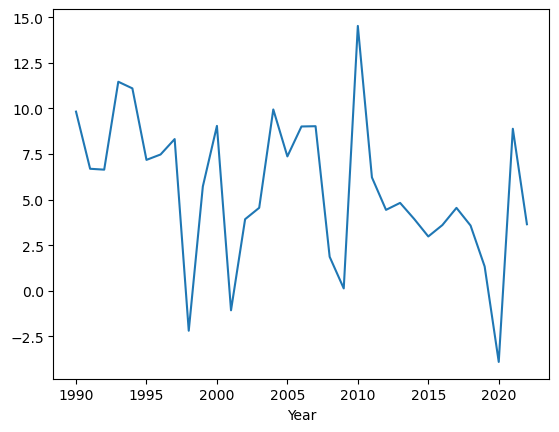

In [247]:
#lineplot for Singapore annual GDP Growth. Notice the sharp drop around year 2020, probably due to COVID lockdowns.
sgpdf['GDP growth (annual %)'].plot(kind="line")

<Axes: xlabel='Year'>

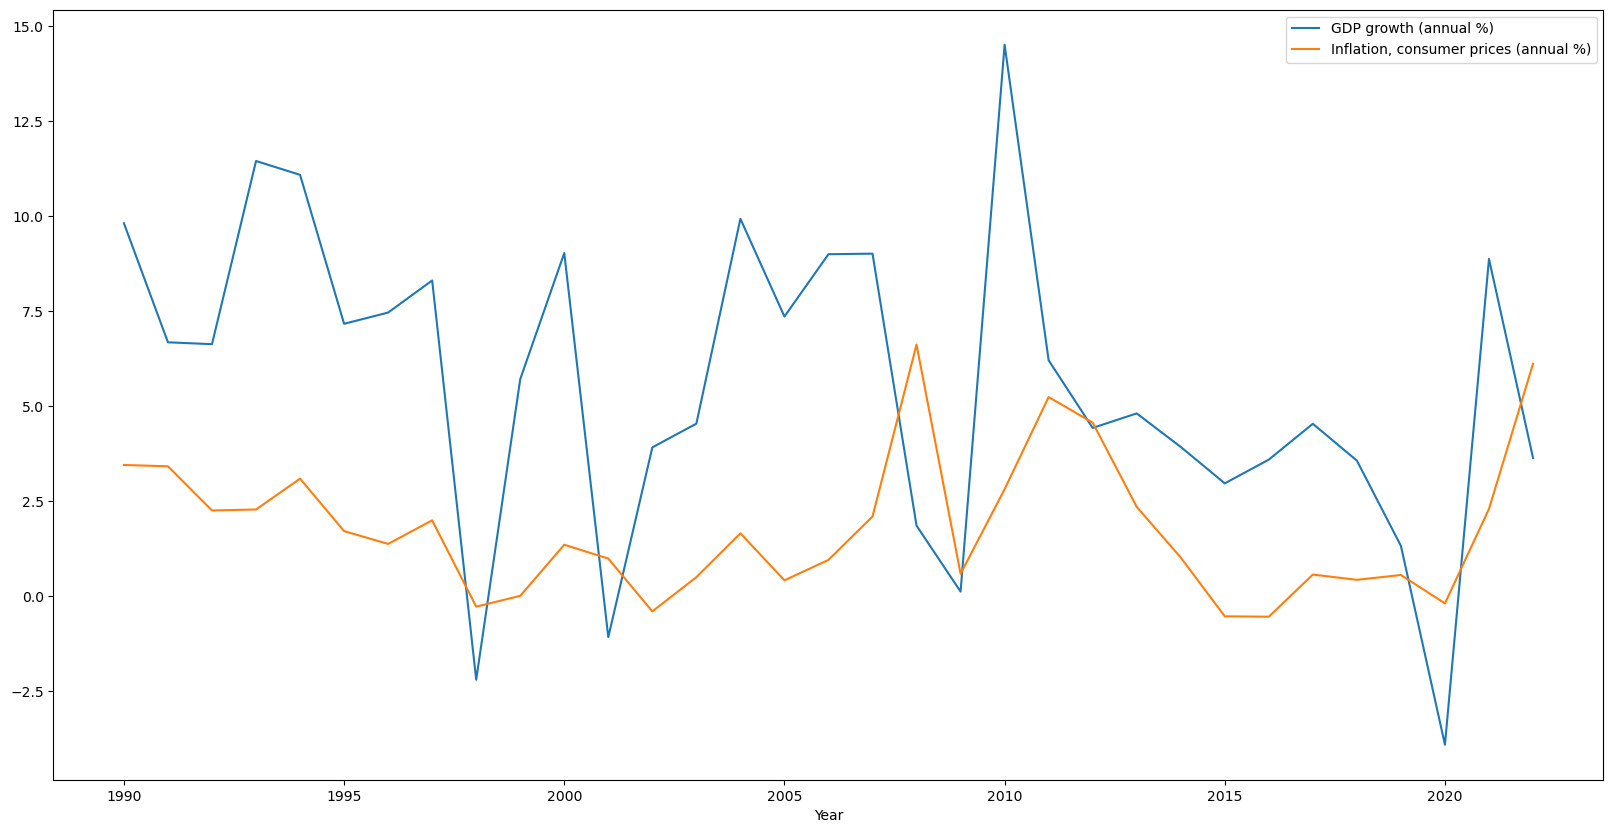

In [248]:
sgpdf[['GDP growth (annual %)','Inflation, consumer prices (annual %)']].plot(kind="line", figsize=(20,10))

#We can see that when the GDP growth goes up, inflation CPI decreases and when the GDP growth goes down, inflation
#CPI goes up(see year 2008). There exists an inverse relationship between the two.

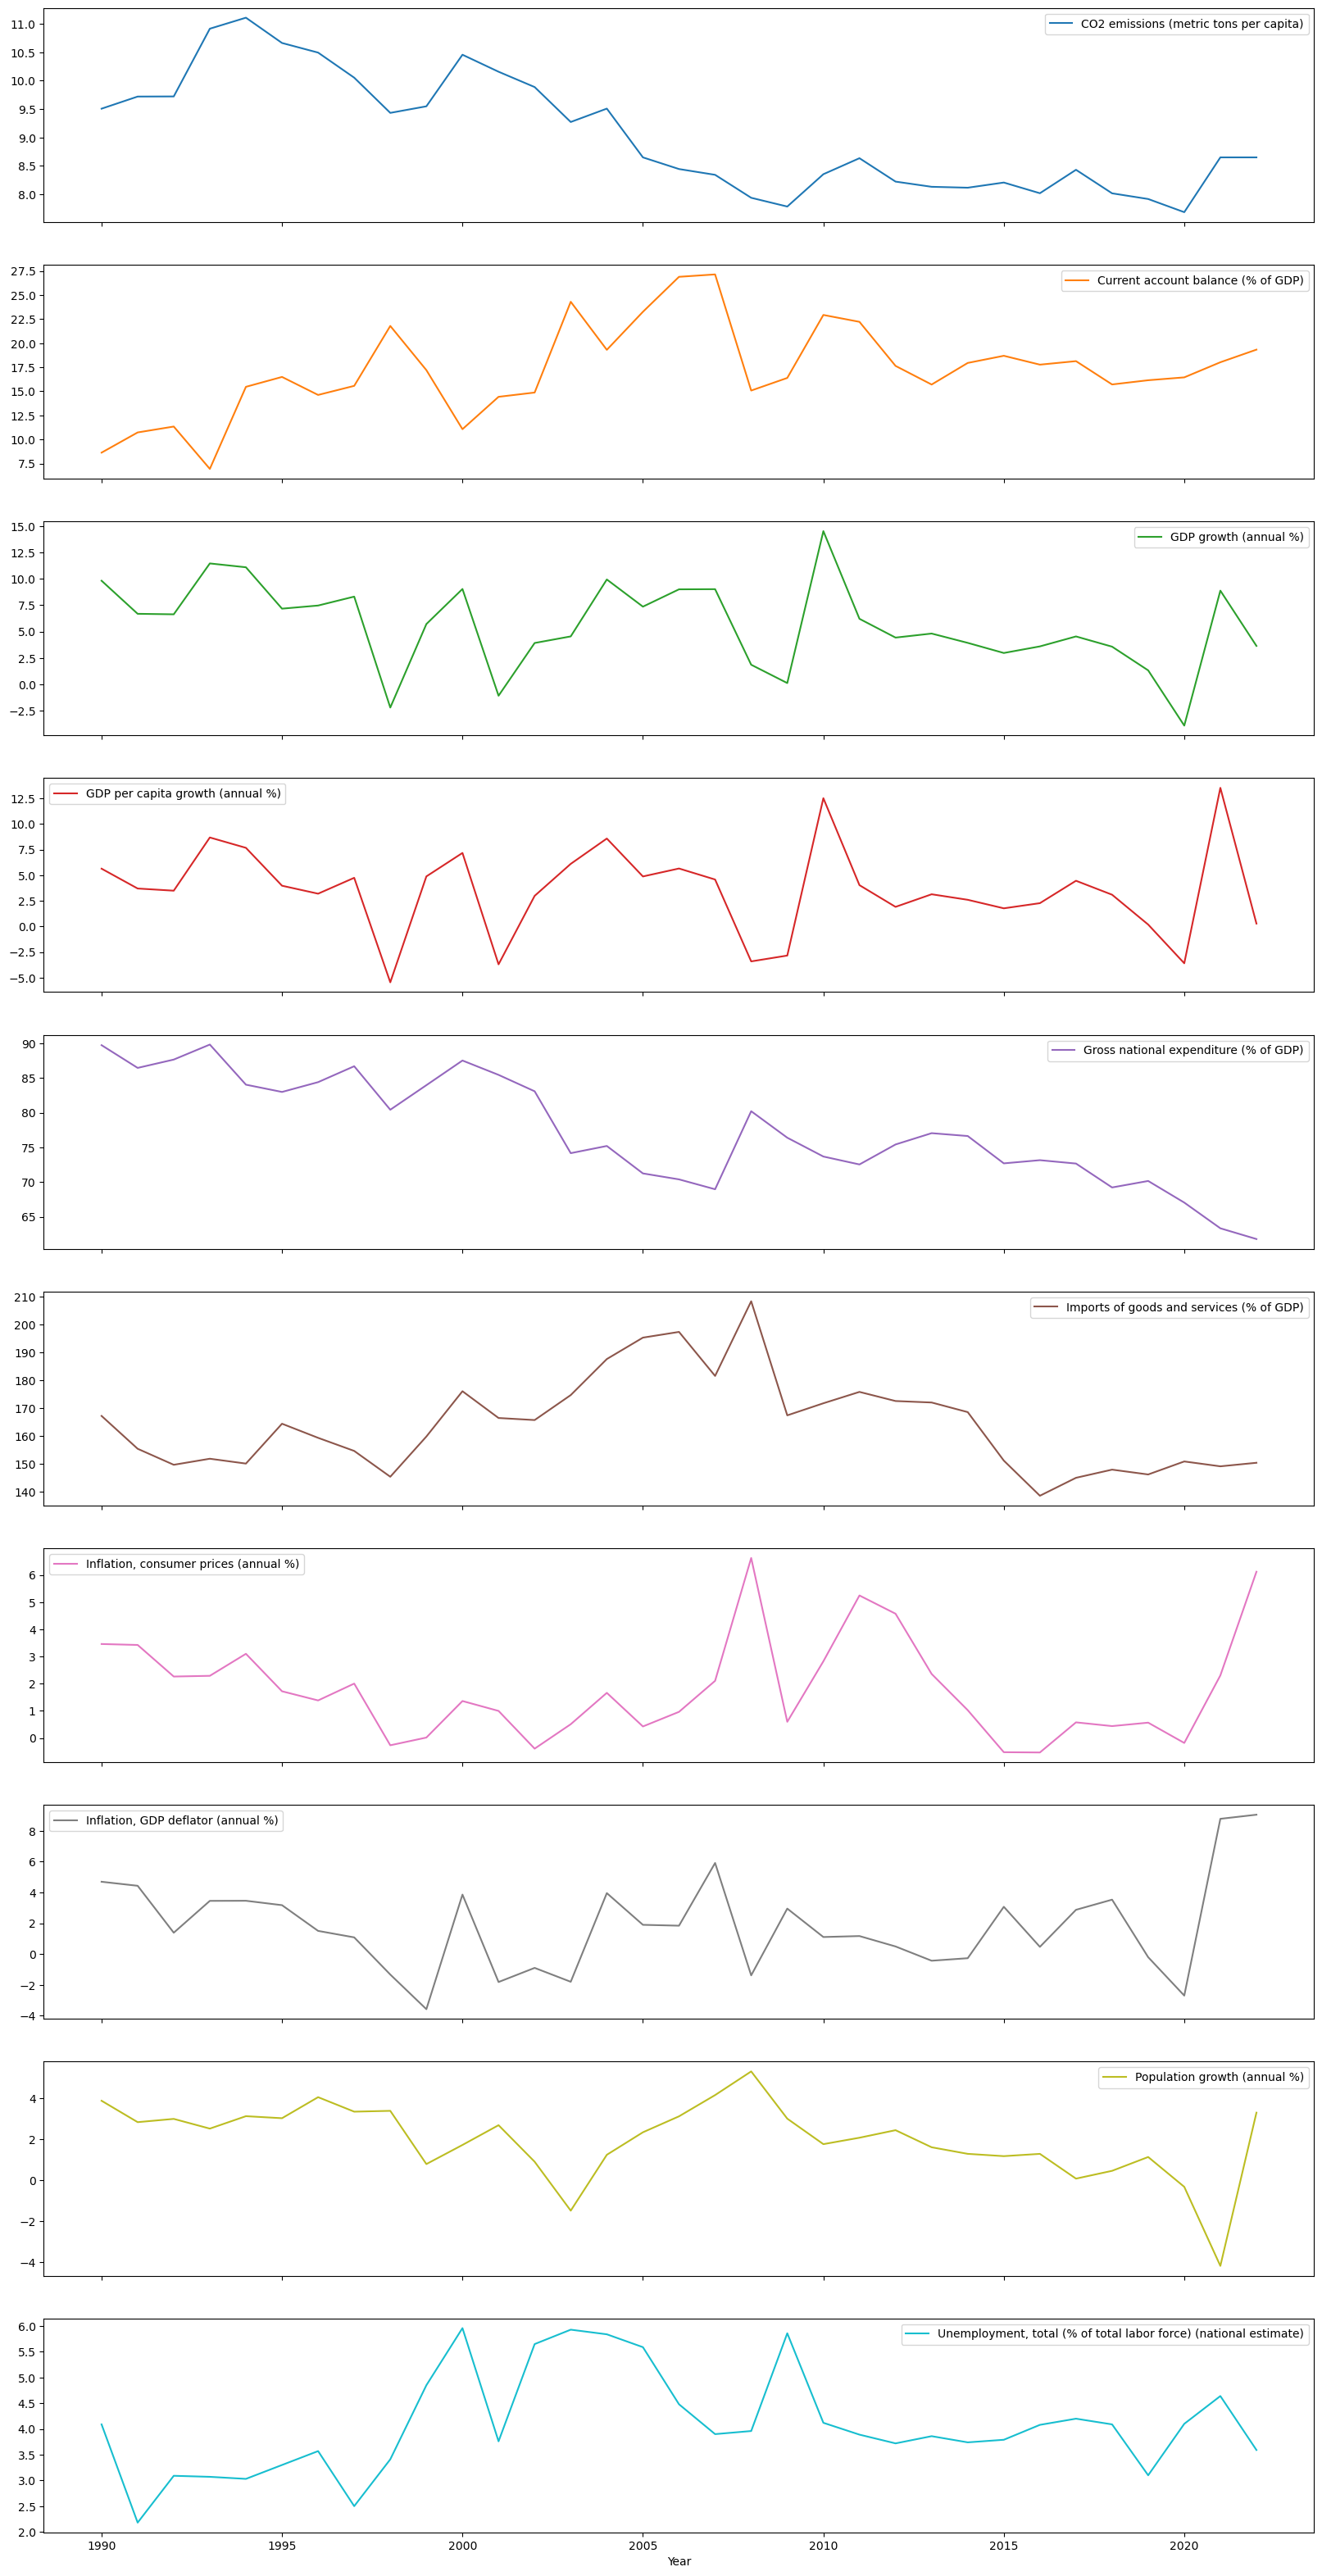

In [249]:
axes = sgpdf.drop('Year',axis=1).plot.line(subplots=True, figsize=(20,40))
#We see the trend going down for CO2 emissions, Gross National Expenditure, Imports of Goods and Services 
#and Unemployment.

#We see an upward trend for Current Account Balance, Inflation CPI, Inflation GDP Deflator and Population Growth.

In [250]:
#Descriptive statistics
sgpdf.drop('Year',axis=1).describe()

#The count, mean, standard deviation, min, max, and quartiles are displayed for all the variables

,CO2 emissions (metric tons per capita),Current account balance (% of GDP),GDP growth (annual %),GDP per capita growth (annual %),Gross national expenditure (% of GDP),Imports of goods and services (% of GDP),"Inflation, consumer prices (annual %)","Inflation, GDP deflator (annual %)",Population growth (annual %),"Unemployment, total (% of total labor force) (national estimate)"
count,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000
mean,9.050429,17.221983,5.592164,3.530976,77.408962,164.124412,1.789415,1.812473,1.981958,4.089065
std,1.010164,4.683998,4.077194,4.291415,7.732693,16.783128,1.854901,2.946486,1.801663,0.989591
min,7.686684,6.948514,-3.901053,-5.457987,61.788407,138.464502,-0.532269,-3.577830,-4.170336,2.180000
25%,8.208109,15.083436,3.601656,1.904462,72.544447,150.309924,0.507905,-0.267270,1.186377,3.570000
50%,8.650600,16.496750,5.718372,3.695382,76.403011,164.338323,1.383181,1.506223,2.350511,3.900000
75%,9.722636,19.311121,8.882354,5.631848,84.051054,172.493353,2.358604,3.462740,3.129389,4.480000
max,11.108004,27.143333,14.519750,13.519127,89.837332,208.332944,6.627782,9.051761,5.321517,5.960000


In [251]:
sgpdf.drop('Year',axis=1).skew() #The skewness is calculated for all the variables.

CO2 emissions (metric tons per capita)                              0.496194
Current account balance (% of GDP)                                  0.122847
GDP growth (annual %)                                              -0.263158
GDP per capita growth (annual %)                                   -0.000074
Gross national expenditure (% of GDP)                              -0.072614
Imports of goods and services (% of GDP)                            0.819405
Inflation, consumer prices (annual %)                               1.038679
Inflation, GDP deflator (annual %)                                  0.531124
Population growth (annual %)                                       -1.265178
Unemployment, total (% of total labor force) (national estimate)    0.519388
dtype: float64

In [252]:
sgpdf.drop('Year',axis=1).kurt() #The kurtosis is calculated for all the variables

CO2 emissions (metric tons per capita)                             -1.009983
Current account balance (% of GDP)                                  0.268443
GDP growth (annual %)                                               0.113183
GDP per capita growth (annual %)                                    0.526622
Gross national expenditure (% of GDP)                              -0.939732
Imports of goods and services (% of GDP)                            0.296460
Inflation, consumer prices (annual %)                               0.719384
Inflation, GDP deflator (annual %)                                  0.450525
Population growth (annual %)                                        3.223087
Unemployment, total (% of total labor force) (national estimate)   -0.190496
dtype: float64

In [253]:
#Univariate plots - histogram, boxplot, densityplot

<Axes: ylabel='Frequency'>

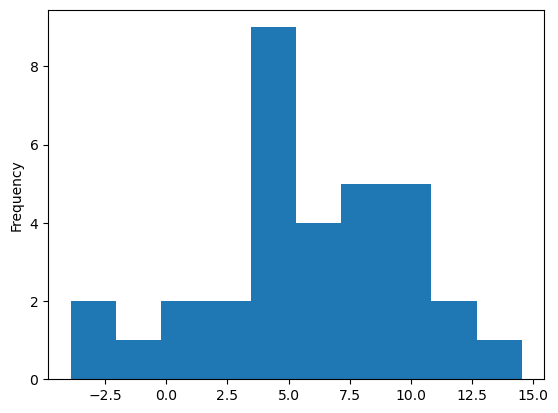

In [254]:
sgpdf['GDP growth (annual %)'].plot(kind="hist") #histogram for GDP growth

<Axes: >

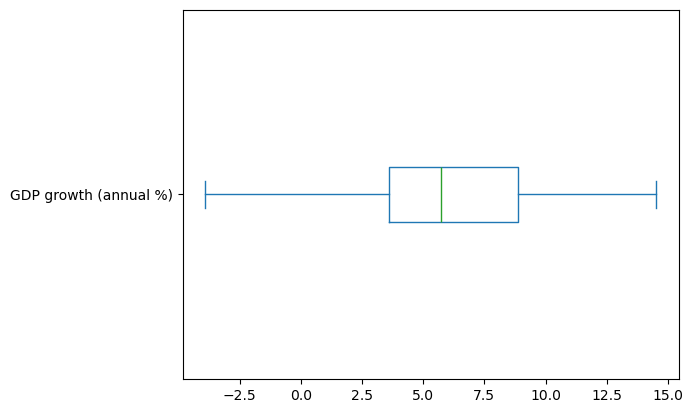

In [255]:
sgpdf['GDP growth (annual %)'].plot(kind="box",vert=False) #boxplot for GDP growth

<Axes: ylabel='Density'>

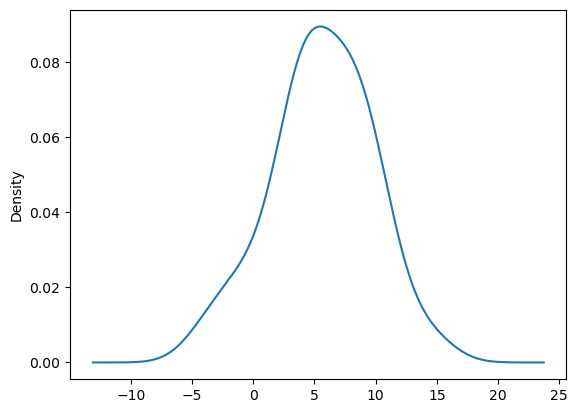

In [256]:
sgpdf['GDP growth (annual %)'].plot(kind="density") #Close to normal distribution.

<Axes: ylabel='Frequency'>

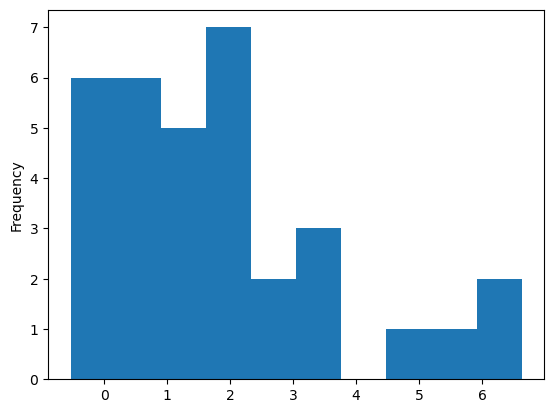

In [257]:
sgpdf['Inflation, consumer prices (annual %)'].plot(kind="hist") #histogram for Inflation CPI

<Axes: >

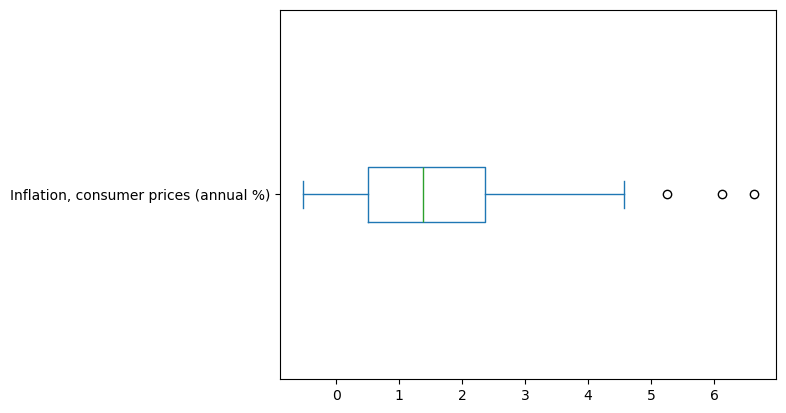

In [258]:
#boxplot for Inflation CPI
sgpdf['Inflation, consumer prices (annual %)'].plot(kind="box", vert=False) 

#We can see that outliers are present for Inflation CPI

<Axes: ylabel='Density'>

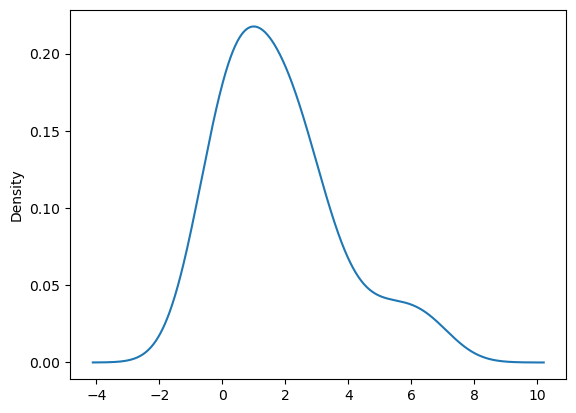

In [259]:
sgpdf['Inflation, consumer prices (annual %)'].plot(kind="density") #Positive skewness is present for Inflation CPI

In [260]:
#Correlation analysis
sgpdf.drop('Year',axis=1).corr()

#We observe that GDP Growth and GDP Per capita have a strong positive correlation of 0.897, this may introduce
#multicollinearity

,CO2 emissions (metric tons per capita),Current account balance (% of GDP),GDP growth (annual %),GDP per capita growth (annual %),Gross national expenditure (% of GDP),Imports of goods and services (% of GDP),"Inflation, consumer prices (annual %)","Inflation, GDP deflator (annual %)",Population growth (annual %),"Unemployment, total (% of total labor force) (national estimate)"
CO2 emissions (metric tons per capita),1.000000,-0.450600,0.419976,0.289626,0.746252,-0.126119,0.022005,0.092322,0.230262,-0.167586
Current account balance (% of GDP),-0.450600,1.000000,-0.018366,0.041688,-0.676384,0.355123,-0.122567,-0.049898,-0.131231,0.292867
GDP growth (annual %),0.419976,-0.018366,1.000000,0.897839,0.224819,0.218979,0.282636,0.469926,0.078379,-0.010290
GDP per capita growth (annual %),0.289626,0.041688,0.897839,1.000000,0.011245,0.068800,0.090546,0.449029,-0.368139,0.158054
Gross national expenditure (% of GDP),0.746252,-0.676384,0.224819,0.011245,1.000000,-0.012255,0.021553,-0.247897,0.447159,-0.222055
Imports of goods and services (% of GDP),-0.126119,0.355123,0.218979,0.068800,-0.012255,1.000000,0.313937,-0.118765,0.314866,0.444592
"Inflation, consumer prices (annual %)",0.022005,-0.122567,0.282636,0.090546,0.021553,0.313937,1.000000,0.348636,0.408169,-0.321232
"Inflation, GDP deflator (annual %)",0.092322,-0.049898,0.469926,0.449029,-0.247897,-0.118765,0.348636,1.000000,-0.012595,-0.067061
Population growth (annual %),0.230262,-0.131231,0.078379,-0.368139,0.447159,0.314866,0.408169,-0.012595,1.000000,-0.377342
"Unemployment, total (% of total labor force) (national estimate)",-0.167586,0.292867,-0.010290,0.158054,-0.222055,0.444592,-0.321232,-0.067061,-0.377342,1.000000


<Axes: >

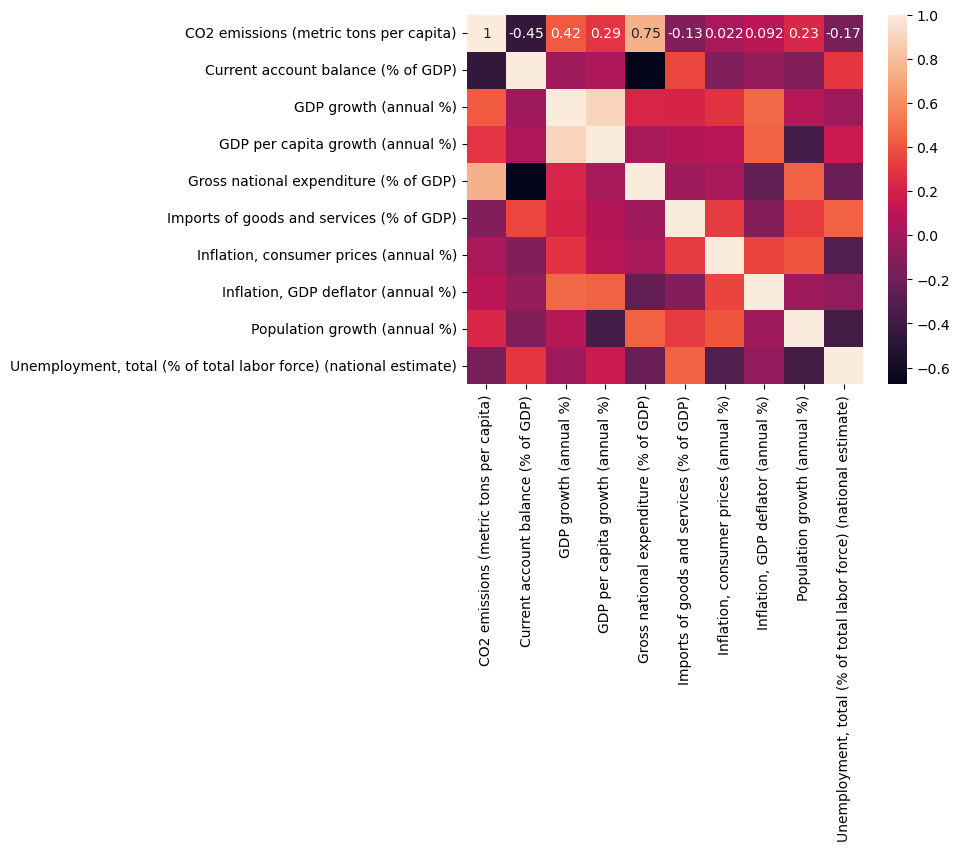

In [261]:
#Heatmap
sg=sgpdf.drop('Year',axis=1).corr()
sns.heatmap(sg, annot=True)

In [262]:
sgpdf.drop('Year',axis=1).cov() #Covariance analysis

,CO2 emissions (metric tons per capita),Current account balance (% of GDP),GDP growth (annual %),GDP per capita growth (annual %),Gross national expenditure (% of GDP),Imports of goods and services (% of GDP),"Inflation, consumer prices (annual %)","Inflation, GDP deflator (annual %)",Population growth (annual %),"Unemployment, total (% of total labor force) (national estimate)"
CO2 emissions (metric tons per capita),1.020431,-2.132062,1.729727,1.255539,5.829188,-2.138191,0.041231,0.274789,0.419071,-0.167527
Current account balance (% of GDP),-2.132062,21.939836,-0.350746,0.837976,-24.498581,27.917015,-1.064904,-0.688653,-1.107458,1.357511
GDP growth (annual %),1.729727,-0.350746,16.623511,15.709429,7.088024,14.984294,2.137515,5.645406,0.575752,-0.041518
GDP per capita growth (annual %),1.255539,0.837976,15.709429,18.416241,0.373141,4.955222,0.720759,5.677787,-2.846337,0.671215
Gross national expenditure (% of GDP),5.829188,-24.498581,7.088024,0.373141,59.794548,-1.590488,0.309139,-5.648146,6.229690,-1.699209
Imports of goods and services (% of GDP),-2.138191,27.917015,14.984294,4.955222,-1.590488,281.673370,9.773175,-5.873061,9.520761,7.383976
"Inflation, consumer prices (annual %)",0.041231,-1.064904,2.137515,0.720759,0.309139,9.773175,3.440658,1.905448,1.364062,-0.589651
"Inflation, GDP deflator (annual %)",0.274789,-0.688653,5.645406,5.677787,-5.648146,-5.873061,1.905448,8.681778,-0.066859,-0.195537
Population growth (annual %),0.419071,-1.107458,0.575752,-2.846337,6.229690,9.520761,1.364062,-0.066859,3.245991,-0.672766
"Unemployment, total (% of total labor force) (national estimate)",-0.167527,1.357511,-0.041518,0.671215,-1.699209,7.383976,-0.589651,-0.195537,-0.672766,0.979290


In [263]:
import warnings
warnings.filterwarnings("ignore")

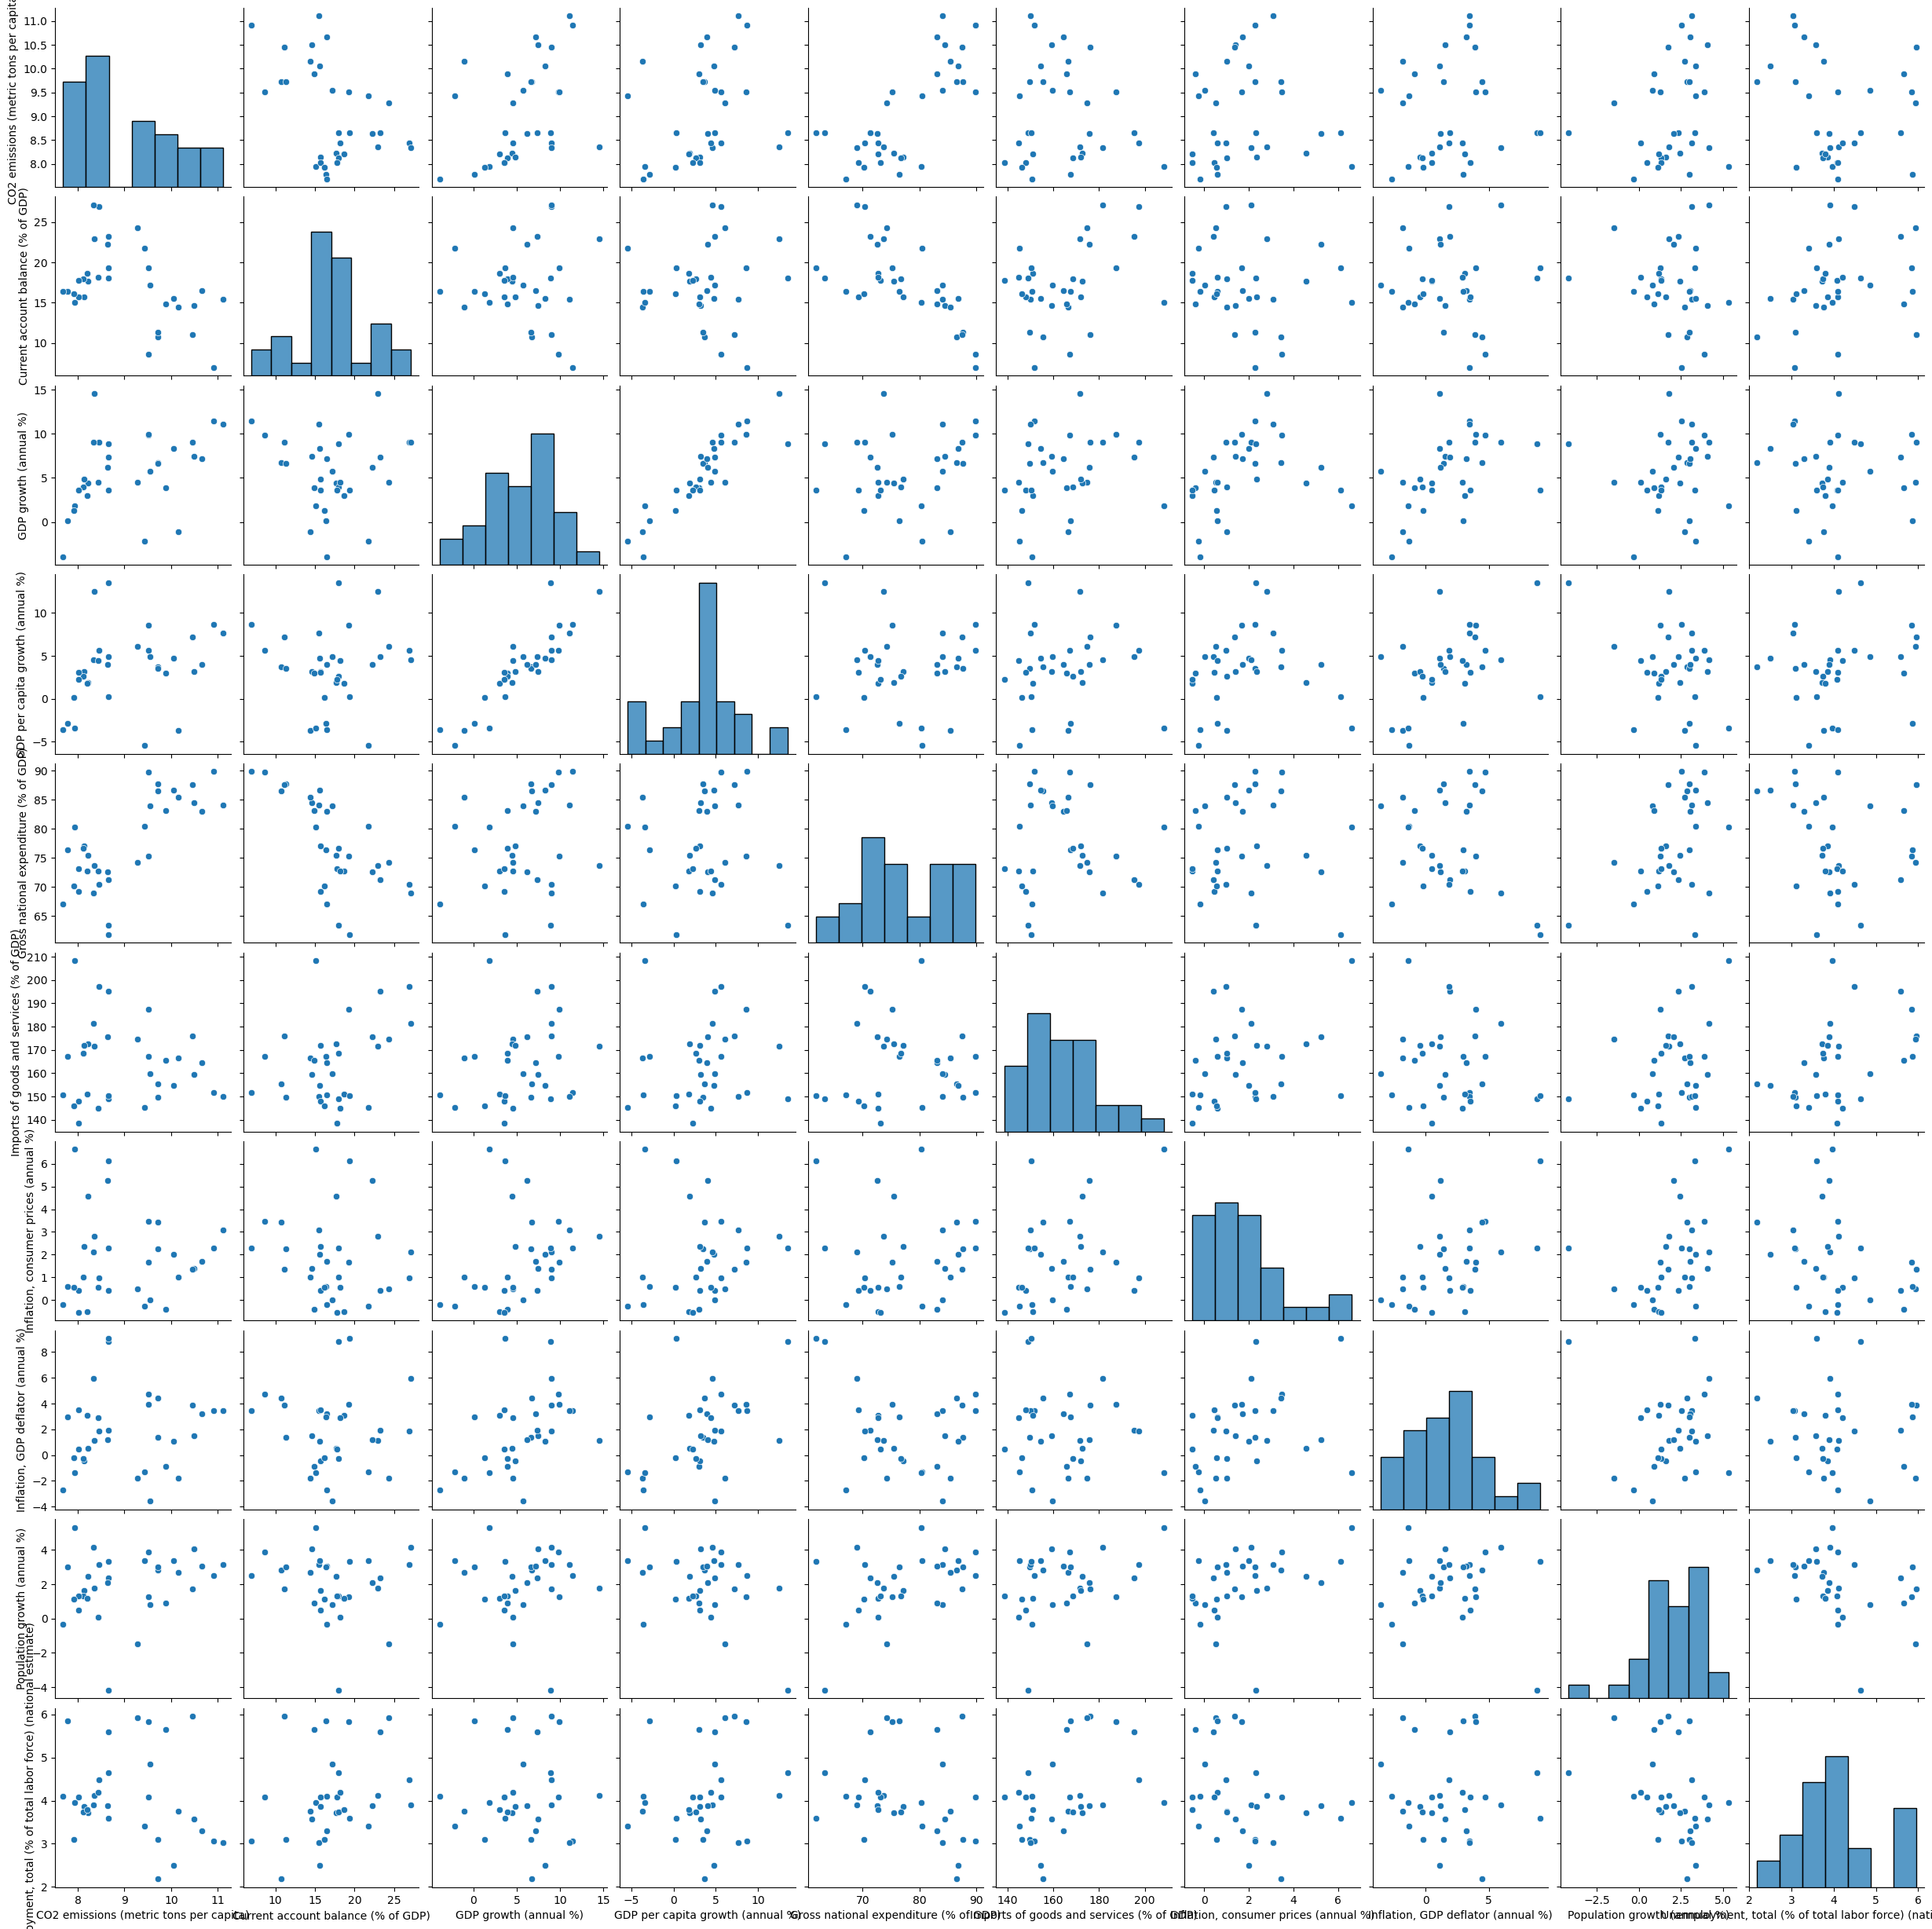

In [264]:
#Pairplot
sns.pairplot(sgpdf.drop('Year',axis=1))

In [265]:
#Test the null average GDP Growth and Inflation CPI equal or identical - Test is 2 sample independent T-test

#Process to be followed is to calculate means, variances and then frame null and alternate hypothesis, 
#conduct T-test and infer based on p-value

sgpdf[['GDP growth (annual %)','Inflation, consumer prices (annual %)']].mean()

GDP growth (annual %)                    5.592164
Inflation, consumer prices (annual %)    1.789415
dtype: float64

In [266]:
sgpdf[['GDP growth (annual %)','Inflation, consumer prices (annual %)']].var()

GDP growth (annual %)                    16.623511
Inflation, consumer prices (annual %)     3.440658
dtype: float64

In [267]:
#Null Hypothesis - There is no significant difference in Average GDP Growth and Inflation CPI
#Alt Hypothesis - There is significant difference in Average GDP Growth and Inflation CPI

In [268]:
from scipy.stats import ttest_ind

In [269]:
ttest_ind(sgpdf['GDP growth (annual %)'],sgpdf['Inflation, consumer prices (annual %)'],equal_var=False)

#Since p-value 1.4023233404736937e-05 is less than 0.05, we can reject the null hypothesis. Thus, we can say 
#that there is a significant difference in Average GDP Growth and Inflation CPI for Singapore

TtestResult(statistic=4.876901462663849, pvalue=1.4023233404736937e-05, df=44.70227450961973)

In [270]:
#Test the null average Population Growth, Inflation CPI and Gross national expenditure are equal or identical

#More than 2 variables - ANOVA single factor
sgpdf[['Inflation, consumer prices (annual %)','Gross national expenditure (% of GDP)','Population growth (annual %)']].mean()

Inflation, consumer prices (annual %)     1.789415
Gross national expenditure (% of GDP)    77.408962
Population growth (annual %)              1.981958
dtype: float64

In [271]:
sgpdf[['Inflation, consumer prices (annual %)','Gross national expenditure (% of GDP)','Population growth (annual %)']].var()

Inflation, consumer prices (annual %)     3.440658
Gross national expenditure (% of GDP)    59.794548
Population growth (annual %)              3.245991
dtype: float64

In [272]:
#Null - There is no significant difference in average Population Growth, Inflation CPI and Gross national expenditure
#Alt - There is significant difference in average Population Growth, Inflation CPI and Gross national expenditure

In [273]:
from scipy.stats import f_oneway

In [274]:
f_oneway(sgpdf['Inflation, consumer prices (annual %)'],sgpdf['Gross national expenditure (% of GDP)'],sgpdf['Population growth (annual %)'])

#Since p-value 4.509609499257661e-86 is less than 0.05, we reject the null hypothesis. Therefore, we can say 
#that atleast one of the means among average Population Growth, Inflation CPI and Gross National Expenditure 
#is different

F_onewayResult(statistic=2831.2542033768646, pvalue=4.509609499257661e-86)

In [275]:
#Linear Regression

In [276]:
#Dependent Variable is GDP Growth and rest all are independent variables
#Removing GDP per capita from the independent variables to take care of multicollinearity

y=sgpdf['GDP growth (annual %)']
X=sgpdf[['CO2 emissions (metric tons per capita)','Current account balance (% of GDP)',
         'Gross national expenditure (% of GDP)','Imports of goods and services (% of GDP)',
         'Inflation, consumer prices (annual %)','Inflation, GDP deflator (annual %)','Population growth (annual %)',
         'Unemployment, total (% of total labor force) (national estimate)']]

In [277]:
y

Year
1990     9.820900
1991     6.688398
1992     6.639806
1993    11.459651
1994    11.095689
1995     7.175401
1996     7.471391
1997     8.316209
1998    -2.191015
1999     5.718372
2000     9.038316
2001    -1.070863
2002     3.923361
2003     4.548255
2004     9.939983
2005     7.366322
2006     9.006766
2007     9.021520
2008     1.863483
2009     0.127953
2010    14.519750
2011     6.214934
2012     4.435498
2013     4.817631
2014     3.935540
2015     2.976799
2016     3.601656
2017     4.544728
2018     3.575433
2019     1.331261
2020    -3.901053
2021     8.882354
2022     3.646972
Name: GDP growth (annual %), dtype: float64

In [278]:
X

,CO2 emissions (metric tons per capita),Current account balance (% of GDP),Gross national expenditure (% of GDP),Imports of goods and services (% of GDP),"Inflation, consumer prices (annual %)","Inflation, GDP deflator (annual %)",Population growth (annual %),"Unemployment, total (% of total labor force) (national estimate)"
Year,,,,,,,,
1990,9.507301,8.637241,89.747958,167.139673,3.460753,4.697423,3.889094,4.089065
1991,9.720604,10.733964,86.470307,155.341801,3.425702,4.435345,2.845483,2.180000
1992,9.722636,11.346066,87.670896,149.586318,2.263071,1.387703,3.004256,3.090000
1993,10.914295,6.948514,89.837332,151.765620,2.289300,3.456187,2.529807,3.070000
1994,11.108004,15.470158,84.051054,150.023189,3.100133,3.462740,3.136587,3.030000
1995,10.663026,16.496750,83.001254,164.338323,1.720534,3.176278,3.037813,3.300000
1996,10.493927,14.627347,84.415646,159.268051,1.383181,1.506223,4.064318,3.570000
1997,10.053008,15.569836,86.709797,154.567536,2.003586,1.084992,3.357442,2.500000
1998,9.433433,21.791551,80.436090,145.291685,-0.267502,-1.328849,3.397212,3.410000


In [279]:
from sklearn.linear_model import LinearRegression

In [280]:
reg_model = LinearRegression().fit(X,y) 

In [281]:
reg_model.score(X,y) #R2 score of 0.6085

0.6085073316559666

In [282]:
reg_model.intercept_ #Intercept of the model is -50.83963340146121

-50.83963340146121

In [283]:
print(list(zip(X.columns,reg_model.coef_))) #printing all the coefficients

[('CO2 emissions (metric tons per capita)', 0.16370419928397112), ('Current account balance (% of GDP)', 0.46489696475938846), ('Gross national expenditure (% of GDP)', 0.47553781856150157), ('Imports of goods and services (% of GDP)', 0.08430467889889348), ('Inflation, consumer prices (annual %)', 0.22936576328249397), ('Inflation, GDP deflator (annual %)', 0.9692431089205293), ('Population growth (annual %)', -1.1077764755688198), ('Unemployment, total (% of total labor force) (national estimate)', -0.8987825790873268)]


In [284]:
#Regression Equation
#GDP Growth = -50.839 + 0.163*CO2Emissions + 0.464*CurrentAccountBalance + 0.475*GrossNationalExpenditure +
#0.084*Imports + 0.229*InflationCPI + 0.969*InflationGDPDeflator - 1.107*PopulationGrowth - 0.898*Unemployment

In [285]:
reg_predict = reg_model.predict(X) #predict y_hat

In [286]:
np.sqrt(np.mean(np.square(y-reg_predict))) #root mean squared error(RMSE) of 2.5121248507173197

2.5121248507173197

In [287]:
print("Actual(y):",np.array(y))
print("Predicted(y_hat):",reg_predict)

Actual(y): [ 9.82089956  6.68839754  6.63980557 11.45965088 11.09568931  7.17540112
  7.47139086  8.31620911 -2.19101501  5.71837176  9.03831633 -1.07086275
  3.92336077  4.54825543  9.93998268  7.36632239  9.00676608  9.02151951
  1.86348345  0.12795338 14.51974971  6.21493417  4.43549759  4.81763099
  3.93554028  2.97679932  3.60165604  4.54472822  3.57543271  1.33126133
 -3.9010534   8.882354    3.64697207]
Predicted(y_hat): [ 8.8646809   9.93096073  6.08721749  8.00627557  8.65728697  9.04197949
  5.31448981  7.85393325  3.15712328  3.41478249  9.26496569  4.30524788
  4.12844062  6.64770167  8.85620452  6.04701111  7.67037105  9.34147639
  3.91217284  2.88880956  6.7605265   6.75194628  4.58769912  3.7950457
  4.66472872  4.64133227  0.42819416  4.79501896  2.49480566 -0.46959786
 -3.33297428 11.13053483  4.9030096 ]
